# PWL Smoothing Performance Evaluation

Benchmarks for the analytical triangular low-pass filter smoothing pipeline
using `VectorizedCurrentSources` with 20K waveforms.

Compares:
- **Dense** smoothing (uniform sampling across full time range)
- **Sparse** smoothing (only samples within active intervals near transitions)

Metrics: wall-clock time, memory usage, output compaction ratio, and numerical accuracy.

In [ ]:
import time

import numpy as np
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt

from analysis.vectorized_sources import VectorizedCurrentSources
from analysis.pwl_smoothing import PWLSmoother

%matplotlib inline

print(f'NumPy {np.__version__}')

## 1. Synthetic Waveform Generation

Generate 20K pulse waveforms with randomized parameters matching
typical PDN current source characteristics.

In [2]:
N_WAVEFORMS = 20_000
SEED = 42

# Simulation window
T_START = 0.0
T_END = 10e-9  # 10 ns

np.random.seed(SEED)

# --- Pulse sources (80% of total) ---
n_pulses = int(N_WAVEFORMS * 0.8)

pulse_v1 = np.zeros(n_pulses)
pulse_v2 = np.random.uniform(0.1, 2.0, n_pulses)  # mA
pulse_delay = np.random.uniform(0.5e-9, 5e-9, n_pulses)
pulse_rt = np.random.uniform(1e-12, 5e-11, n_pulses)
pulse_ft = np.random.uniform(1e-12, 5e-11, n_pulses)
pulse_width = np.random.uniform(5e-12, 1e-10, n_pulses)
pulse_period = np.full(n_pulses, T_END)  # One period = simulation window

# --- PWL sources (20% of total) ---
n_pwls = N_WAVEFORMS - n_pulses
pwl_points_per_source = 8  # Average breakpoints per PWL

pwl_times_list = []
pwl_values_list = []
pwl_offsets = []
pwl_counts = []
pwl_periods = []
pwl_delays = []

for i in range(n_pwls):
    n_pts = np.random.randint(4, 12)
    t_pts = np.sort(np.random.uniform(0, T_END, n_pts))
    t_pts[0] = 0.0
    t_pts[-1] = T_END
    v_pts = np.random.uniform(0, 1.5, n_pts)  # mA

    pwl_offsets.append(len(pwl_times_list))
    pwl_counts.append(n_pts)
    pwl_periods.append(T_END)
    pwl_delays.append(0.0)
    pwl_times_list.extend(t_pts.tolist())
    pwl_values_list.extend(v_pts.tolist())

# Build VectorizedCurrentSources
n_nodes = N_WAVEFORMS  # 1 node per source for simplicity
node_to_idx = {f'n{i}': i for i in range(n_nodes)}

sources = VectorizedCurrentSources(
    n_nodes=n_nodes,
    node_to_idx=node_to_idx,
    n_sources=N_WAVEFORMS,
    dc_values=np.random.uniform(0, 0.5, N_WAVEFORMS),
    source_node_idx=np.arange(N_WAVEFORMS, dtype=np.int32),
    # Pulses
    n_pulses=n_pulses,
    pulse_node_idx=np.arange(n_pulses, dtype=np.int32),
    pulse_source_idx=np.arange(n_pulses, dtype=np.int32),
    pulse_v1=pulse_v1,
    pulse_v2=pulse_v2,
    pulse_delay=pulse_delay,
    pulse_rt=pulse_rt,
    pulse_ft=pulse_ft,
    pulse_width=pulse_width,
    pulse_period=pulse_period,
    # PWLs
    n_pwls=n_pwls,
    n_pwl_points=len(pwl_times_list),
    pwl_node_idx=np.arange(n_pulses, n_pulses + n_pwls, dtype=np.int32),
    pwl_source_idx=np.arange(n_pulses, n_pulses + n_pwls, dtype=np.int32),
    pwl_period=np.array(pwl_periods),
    pwl_delay=np.array(pwl_delays),
    pwl_offset=np.array(pwl_offsets, dtype=np.int32),
    pwl_count=np.array(pwl_counts, dtype=np.int32),
    pwl_times=np.array(pwl_times_list),
    pwl_values=np.array(pwl_values_list),
)

mem_mb = sources.memory_bytes() / (1024 * 1024)
print(f'Sources: {N_WAVEFORMS:,} total ({n_pulses:,} pulses + {n_pwls:,} PWLs)')
print(f'PWL breakpoints: {len(pwl_times_list):,}')
print(f'Memory: {mem_mb:.2f} MB')

Sources: 20,000 total (16,000 pulses + 4,000 PWLs)
PWL breakpoints: 29,705
Memory: 1.78 MB


## 2. Smoothing Performance: Dense vs Sparse

Benchmark `create_smoothed_cache` at multiple time-step values.
Smaller `time_step` means more samples and should benefit more from sparse mode.

In [3]:
time_steps = [0.1e-9, 0.05e-9, 0.02e-9, 0.01e-9]
labels = ['100ps', '50ps', '20ps', '10ps']

results = []

for dt, label in zip(time_steps, labels):
    n_uniform_samples = int((T_END - T_START) / dt) + 1
    print(f'\n--- time_step = {label} ({n_uniform_samples:,} uniform samples) ---')

    smoother = PWLSmoother(time_step=dt, compact_threshold=1e-12)

    # Dense path
    t0 = time.perf_counter()
    cache_dense = smoother.create_smoothed_cache(
        sources, T_START, T_END, chunk_size=5000, sparse_threshold=0
    )
    dense_time = time.perf_counter() - t0
    stats_dense = smoother.get_statistics()

    # Sparse path
    t0 = time.perf_counter()
    cache_sparse = smoother.create_smoothed_cache(
        sources, T_START, T_END, chunk_size=5000, sparse_threshold=100e-12
    )
    sparse_time = time.perf_counter() - t0
    stats_sparse = smoother.get_statistics()

    speedup = dense_time / sparse_time if sparse_time > 0 else float('inf')

    print(f'  Dense:  {dense_time:.3f}s  ({stats_dense["smoothed_points"]:,} points)')
    print(f'  Sparse: {sparse_time:.3f}s  ({stats_sparse["smoothed_points"]:,} points)')
    print(f'  Speedup: {speedup:.1f}x')

    results.append({
        'label': label,
        'dt': dt,
        'n_samples': n_uniform_samples,
        'dense_time': dense_time,
        'sparse_time': sparse_time,
        'speedup': speedup,
        'dense_points': stats_dense['smoothed_points'],
        'sparse_points': stats_sparse['smoothed_points'],
        'cache_dense': cache_dense,
        'cache_sparse': cache_sparse,
    })


--- time_step = 100ps (101 uniform samples) ---
  Dense:  2.926s  (511,817 points)
  Sparse: 2.760s  (511,817 points)
  Speedup: 1.1x

--- time_step = 50ps (201 uniform samples) ---
  Dense:  3.714s  (924,064 points)
  Sparse: 2.410s  (207,113 points)
  Speedup: 1.5x

--- time_step = 20ps (501 uniform samples) ---
  Dense:  6.410s  (2,127,707 points)
  Sparse: 2.717s  (256,996 points)
  Speedup: 2.4x

--- time_step = 10ps (1,001 uniform samples) ---
  Dense:  12.494s  (4,107,502 points)
  Sparse: 3.251s  (311,859 points)
  Speedup: 3.8x


In [4]:
# Summary table
print(f'{"dt":>8s}  {"Dense (s)":>10s}  {"Sparse (s)":>10s}  {"Speedup":>8s}  {"Dense pts":>10s}  {"Sparse pts":>10s}  {"Compaction":>10s}')
print('-' * 78)
for r in results:
    compaction = r['dense_points'] / r['sparse_points'] if r['sparse_points'] > 0 else 0
    print(
        f'{r["label"]:>8s}  {r["dense_time"]:10.3f}  {r["sparse_time"]:10.3f}  '
        f'{r["speedup"]:7.1f}x  {r["dense_points"]:>10,}  {r["sparse_points"]:>10,}  '
        f'{compaction:9.1f}x'
    )

      dt   Dense (s)  Sparse (s)   Speedup   Dense pts  Sparse pts  Compaction
------------------------------------------------------------------------------
   100ps       2.926       2.760      1.1x     511,817     511,817        1.0x
    50ps       3.714       2.410      1.5x     924,064     207,113        4.5x
    20ps       6.410       2.717      2.4x   2,127,707     256,996        8.3x
    10ps      12.494       3.251      3.8x   4,107,502     311,859       13.2x


## 3. Speedup Visualization

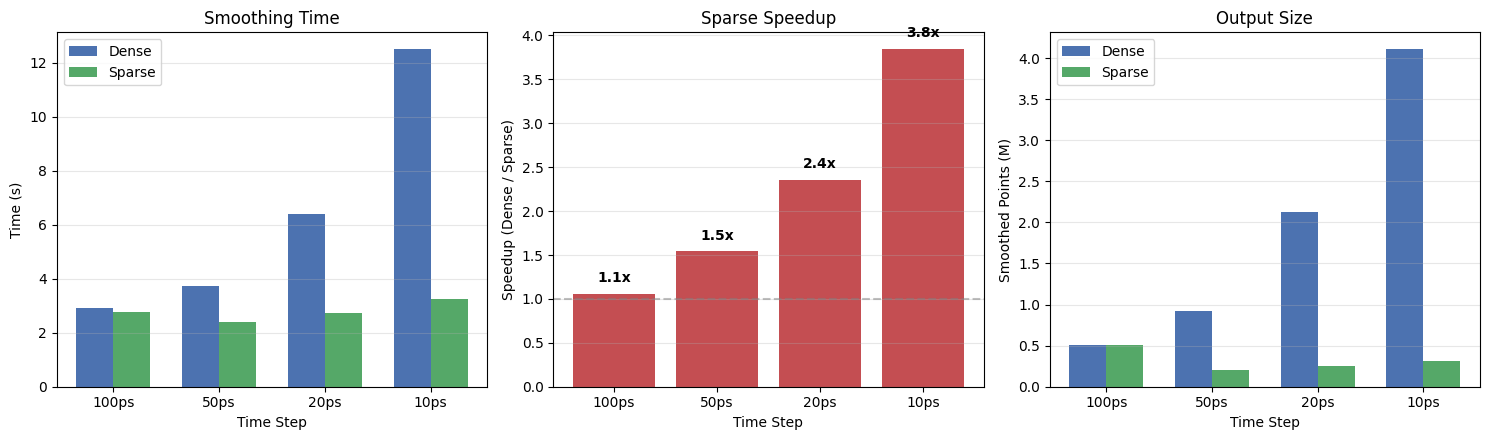

Saved: smoothing_perf_summary.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

x_labels = [r['label'] for r in results]
x = np.arange(len(x_labels))
bar_w = 0.35

# --- Panel 1: Wall-clock time ---
ax = axes[0]
dense_times = [r['dense_time'] for r in results]
sparse_times = [r['sparse_time'] for r in results]
ax.bar(x - bar_w/2, dense_times, bar_w, label='Dense', color='#4C72B0')
ax.bar(x + bar_w/2, sparse_times, bar_w, label='Sparse', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Time Step')
ax.set_ylabel('Time (s)')
ax.set_title('Smoothing Time')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# --- Panel 2: Speedup ---
ax = axes[1]
speedups = [r['speedup'] for r in results]
bars = ax.bar(x, speedups, color='#C44E52')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
for bar, s in zip(bars, speedups):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{s:.1f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Time Step')
ax.set_ylabel('Speedup (Dense / Sparse)')
ax.set_title('Sparse Speedup')
ax.grid(axis='y', alpha=0.3)

# --- Panel 3: Output compaction ---
ax = axes[2]
dense_pts = [r['dense_points'] / 1e6 for r in results]
sparse_pts = [r['sparse_points'] / 1e6 for r in results]
ax.bar(x - bar_w/2, dense_pts, bar_w, label='Dense', color='#4C72B0')
ax.bar(x + bar_w/2, sparse_pts, bar_w, label='Sparse', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Time Step')
ax.set_ylabel('Smoothed Points (M)')
ax.set_title('Output Size')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
#plt.savefig('smoothing_perf_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: smoothing_perf_summary.png')

## 4. Numerical Accuracy: Sparse vs Dense

Apply both caches and compare `evaluate_at_time` across the simulation window.

In [6]:
# Use 50ps time step for accuracy comparison
dt_test = 0.05e-9
smoother = PWLSmoother(time_step=dt_test, compact_threshold=1e-12)

cache_dense = smoother.create_smoothed_cache(
    sources, T_START, T_END, sparse_threshold=0
)
cache_sparse = smoother.create_smoothed_cache(
    sources, T_START, T_END, sparse_threshold=100e-12
)

smoothed_dense = smoother.apply_cache_to_sources(sources, cache_dense)
smoothed_sparse = smoother.apply_cache_to_sources(sources, cache_sparse)

# Evaluate at 101 time points
eval_times = np.linspace(T_START, T_END, 101)
max_diffs = []
mean_diffs = []
total_dense = []
total_sparse = []

for t in eval_times:
    curr_d = smoothed_dense.evaluate_at_time(t)
    curr_s = smoothed_sparse.evaluate_at_time(t)
    diff = np.abs(curr_d - curr_s)
    max_diffs.append(np.max(diff))
    mean_diffs.append(np.mean(diff))
    total_dense.append(np.sum(curr_d))
    total_sparse.append(np.sum(curr_s))

max_diffs = np.array(max_diffs)
mean_diffs = np.array(mean_diffs)

print(f'Max absolute difference:  {np.max(max_diffs):.6f} mA')
print(f'Mean absolute difference: {np.mean(mean_diffs):.6f} mA')
print(f'Max relative to peak:     {np.max(max_diffs) / max(np.max(total_dense), 1e-15) * 100:.4f}%')

Max absolute difference:  0.236518 mA
Mean absolute difference: 0.000053 mA
Max relative to peak:     0.0028%


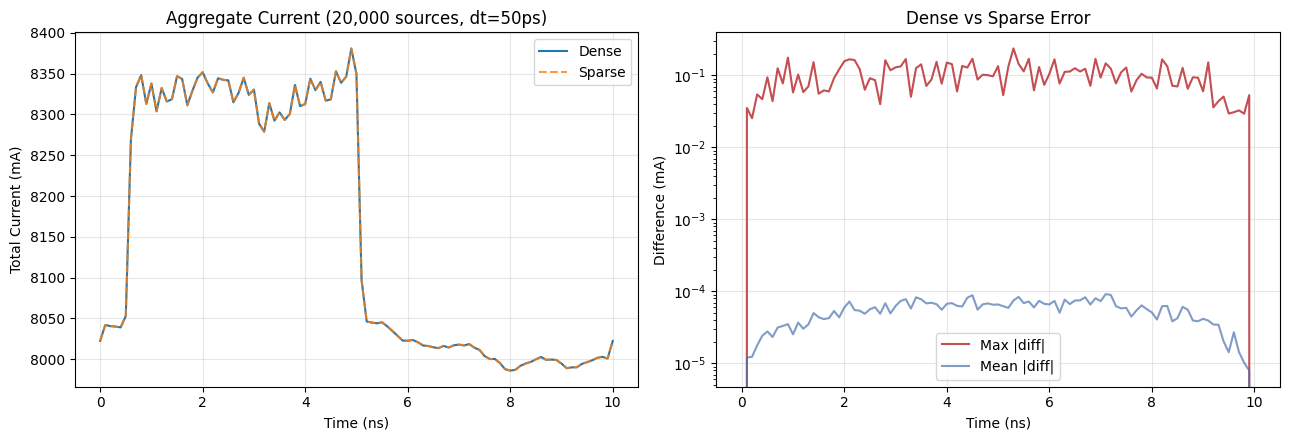

Saved: smoothing_accuracy.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Panel 1: Total current comparison ---
ax = axes[0]
ax.plot(eval_times * 1e9, total_dense, label='Dense', linewidth=1.5)
ax.plot(eval_times * 1e9, total_sparse, '--', label='Sparse', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Total Current (mA)')
ax.set_title(f'Aggregate Current ({N_WAVEFORMS:,} sources, dt={dt_test*1e12:.0f}ps)')
ax.legend()
ax.grid(alpha=0.3)

# --- Panel 2: Error over time ---
ax = axes[1]
ax.semilogy(eval_times * 1e9, max_diffs, label='Max |diff|', color='#C44E52')
ax.semilogy(eval_times * 1e9, mean_diffs, label='Mean |diff|', color='#4C72B0', alpha=0.7)
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Difference (mA)')
ax.set_title('Dense vs Sparse Error')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('smoothing_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: smoothing_accuracy.png')

## 5. Evaluation Throughput

Benchmark `evaluate_at_time` on original vs smoothed sources.

In [8]:
N_EVAL = 100
eval_t = np.random.uniform(T_START, T_END, N_EVAL)

# Original sources
t0 = time.perf_counter()
for t in eval_t:
    _ = sources.evaluate_at_time(t)
original_time = time.perf_counter() - t0

# Smoothed sources (sparse cache applied)
t0 = time.perf_counter()
for t in eval_t:
    _ = smoothed_sparse.evaluate_at_time(t)
smoothed_time = time.perf_counter() - t0

print(f'evaluate_at_time ({N_EVAL} calls, {N_WAVEFORMS:,} sources):')
print(f'  Original:  {original_time:.3f}s  ({original_time/N_EVAL*1000:.1f} ms/call)')
print(f'  Smoothed:  {smoothed_time:.3f}s  ({smoothed_time/N_EVAL*1000:.1f} ms/call)')
print(f'  Ratio:     {original_time/smoothed_time:.1f}x')

evaluate_at_time (100 calls, 20,000 sources):
  Original:  0.058s  (0.6 ms/call)
  Smoothed:  0.099s  (1.0 ms/call)
  Ratio:     0.6x


## 6. Memory Analysis

In [9]:
def cache_memory_mb(cache):
    """Estimate memory of a SmoothedWaveformCache."""
    arrays = [
        cache.pwl_times, cache.pwl_values,
        cache.pwl_offset, cache.pwl_count,
        cache.pwl_period, cache.pwl_delay, cache.pwl_node_idx,
    ]
    return sum(a.nbytes for a in arrays) / (1024 * 1024)

print(f'{"dt":>8s}  {"Dense Cache":>12s}  {"Sparse Cache":>12s}  {"Ratio":>8s}')
print('-' * 50)
for r in results:
    d_mb = cache_memory_mb(r['cache_dense'])
    s_mb = cache_memory_mb(r['cache_sparse'])
    ratio = d_mb / s_mb if s_mb > 0 else 0
    print(f'{r["label"]:>8s}  {d_mb:10.2f} MB  {s_mb:10.2f} MB  {ratio:7.1f}x')

print(f'\nOriginal sources: {sources.memory_bytes() / (1024*1024):.2f} MB')

      dt   Dense Cache  Sparse Cache     Ratio
--------------------------------------------------
   100ps        8.34 MB        8.34 MB      1.0x
    50ps       14.63 MB        3.69 MB      4.0x
    20ps       33.00 MB        4.46 MB      7.4x
    10ps       63.21 MB        5.29 MB     11.9x

Original sources: 1.78 MB


## 7. Waveform Visualization

Compare original, dense-smoothed, and sparse-smoothed waveforms for a few representative sources.

Fast Rise/Fall: delay=1.24ns, rt=1.0ps, ft=9.5ps, width=0.04ns, v2=1.068mA
Slow Rise/Fall: delay=1.25ns, rt=50.0ps, ft=6.3ps, width=0.07ns, v2=0.688mA
Short Pulse Width: delay=2.87ns, rt=21.0ps, ft=29.4ps, width=0.01ns, v2=1.107mA


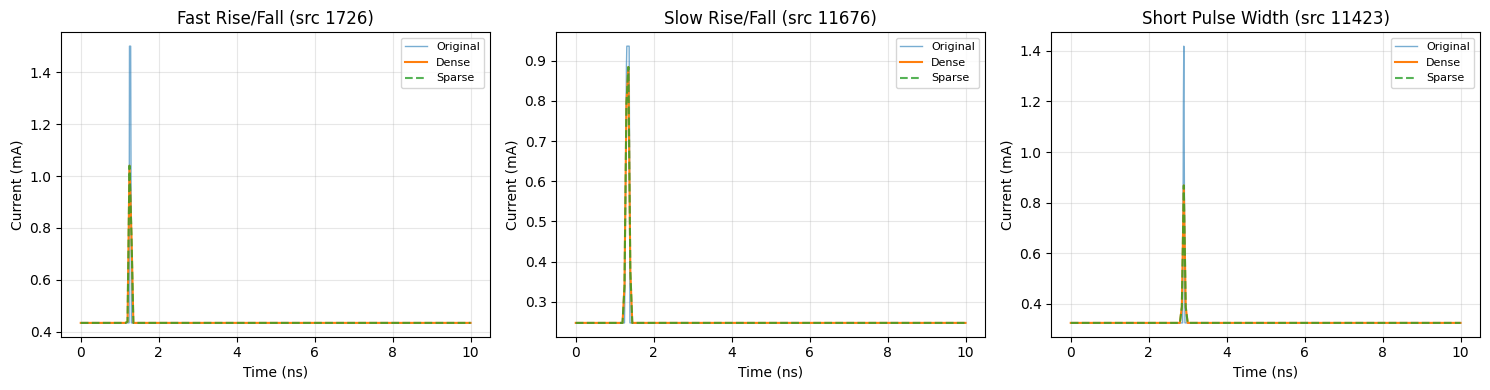

Saved: smoothing_waveforms.png


In [10]:
# Pick 3 representative pulse sources with different characteristics
# 1: fast rise/fall, 2: slow rise/fall, 3: short width
idx_fast = np.argmin(pulse_rt[:n_pulses])  # Fastest rise time
idx_slow = np.argmax(pulse_rt[:n_pulses])  # Slowest rise time
idx_short = np.argmin(pulse_width[:n_pulses])  # Shortest pulse

sample_indices = [idx_fast, idx_slow, idx_short]
titles = ['Fast Rise/Fall', 'Slow Rise/Fall', 'Short Pulse Width']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

t_fine = np.linspace(T_START, T_END, 1001)

for ax, src_idx, title in zip(axes, sample_indices, titles):
    node_idx = src_idx

    # Evaluate at fine time grid
    orig_vals = [sources.evaluate_at_time(t)[node_idx] for t in t_fine]
    dense_vals = [smoothed_dense.evaluate_at_time(t)[node_idx] for t in t_fine]
    sparse_vals = [smoothed_sparse.evaluate_at_time(t)[node_idx] for t in t_fine]

    ax.plot(t_fine * 1e9, orig_vals, label='Original', linewidth=1.0, alpha=0.6)
    ax.plot(t_fine * 1e9, dense_vals, label='Dense', linewidth=1.5)
    ax.plot(t_fine * 1e9, sparse_vals, '--', label='Sparse', linewidth=1.5, alpha=0.8)
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Current (mA)')
    ax.set_title(f'{title} (src {src_idx})')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Print pulse parameters
    print(f'{title}: delay={pulse_delay[src_idx]*1e9:.2f}ns, '
          f'rt={pulse_rt[src_idx]*1e12:.1f}ps, '
          f'ft={pulse_ft[src_idx]*1e12:.1f}ps, '
          f'width={pulse_width[src_idx]*1e9:.2f}ns, '
          f'v2={pulse_v2[src_idx]:.3f}mA')

plt.tight_layout()
#plt.savefig('smoothing_waveforms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: smoothing_waveforms.png')

## 8. Chunk Size Sensitivity

Measure how `chunk_size` affects smoothing time (sparse path at 10ps).

  chunk_size=  1000:  3.135s
  chunk_size=  2000:  3.212s
  chunk_size=  5000:  3.276s
  chunk_size= 10000:  3.272s
  chunk_size= 20000:  3.270s


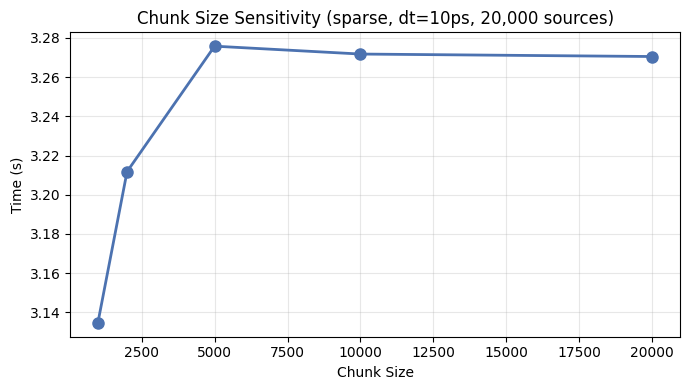

Saved: smoothing_chunk_sensitivity.png


In [11]:
dt_bench = 0.01e-9  # 10ps
chunk_sizes = [1000, 2000, 5000, 10000, 20000]
chunk_results = []

smoother = PWLSmoother(time_step=dt_bench, compact_threshold=1e-12)

for cs in chunk_sizes:
    t0 = time.perf_counter()
    _ = smoother.create_smoothed_cache(
        sources, T_START, T_END, chunk_size=cs, sparse_threshold=100e-12
    )
    elapsed = time.perf_counter() - t0
    chunk_results.append((cs, elapsed))
    print(f'  chunk_size={cs:>6d}:  {elapsed:.3f}s')

fig, ax = plt.subplots(figsize=(7, 4))
cs_vals, times_vals = zip(*chunk_results)
ax.plot(cs_vals, times_vals, 'o-', color='#4C72B0', linewidth=2, markersize=8)
ax.set_xlabel('Chunk Size')
ax.set_ylabel('Time (s)')
ax.set_title(f'Chunk Size Sensitivity (sparse, dt=10ps, {N_WAVEFORMS:,} sources)')
ax.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig('smoothing_chunk_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: smoothing_chunk_sensitivity.png')